In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import sigpy as sp
import sigpy.plot as pl
import numpy as np
import os

In [2]:
os.listdir("/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project")

ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

In [3]:
print("k space array shape: {}".format(ksp.shape))
print("coordinate array shape: {}".format(coord.shape))

dcf = (coord[...,0]**2 + coord[...,1]**2)**0.5

img_grid = sp.nufft_adjoint(dcf*ksp, coord)

img_rss = np.sum(np.abs(img_grid)**2, axis=0)**0.5
#pl.ImagePlot(img_rss, title='test')

k space array shape: (12, 96, 512)
coordinate array shape: (96, 512, 2)


## Goal: Generate Single k-Space Dataset

**Objectives:**

1. Use the density compensation function (DCF), k-space data (`ksp`), and trajectory coordinates (`coord`) to reconstruct an image.
2. Apply a non-uniform fast Fourier transform (NUFFT) to convert the reconstructed image back into a single k-space dataset.

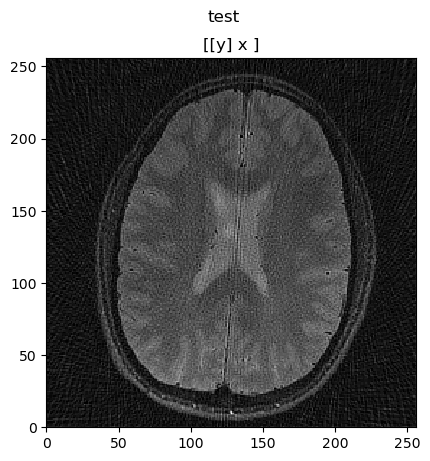

In [ ]:
dcf = (coord[...,0]**2 + coord[...,1]**2)**0.5

img_grid = sp.nufft_adjoint(dcf*ksp, coord)

img_rss = np.sum(np.abs(img_grid)**2, axis=0)**0.5


img_complex = img_rss.astype(complex)
ksp_combined = sp.nufft(img_complex, coord)



img_grid2 = sp.nufft_adjoint(ksp_combined * dcf, coord)
img2 = np.abs(img_grid2)
pl.ImagePlot(img2, title='test')


In [ ]:
'''import numpy as np

num_spokes = coord.shape[0]

# Get the tip of  spoke
spoke_tips = coord[:, -1, :]

# Calculate angle of each spoke from positive kx. 
angles = np.arctan2(spoke_tips[:, 1], spoke_tips[:, 0]) 
angles_deg = np.degrees(angles)

# "True north" = pointing in +ky direction = 90 degrees
# Find spoke whose tip angle is closest to +90 degrees (pi/2)
target_angle = np.pi / 2
angle_diff = np.angle(np.exp(1j * (angles - target_angle)))

north_spoke_idx = np.argmin(np.abs(angle_diff))

print(north_spoke_idx)
print(f"Spoke angle: {angles_deg[north_spoke_idx]:.2f} degrees")
print(f"Spoke tip coords: kx={spoke_tips[north_spoke_idx, 0]:.4f}, ky={spoke_tips[north_spoke_idx, 1]:.4f}")'''

True north spoke index: 48
Spoke angle: 90.00 degrees
Spoke tip coords: kx=0.0000, ky=128.0000


## Goal: Generate Radial Data

**Objectives:**

1. For each spoke, bifurcate at midpoint then flip FIRST spoke
2. Move second spoke to len(spokes) + 1
3. Do same thing for coord data
4. Extend by converting coord data cartesian --> spherical??

In [ ]:
'''n_spokes, n_points, n_dims = coord.shape
half = n_points // 2

ksp_new = np.zeros((n_spokes *2, half), dtype=ksp.dtype)
coord_new = np.zeros((n_spokes * 2, half, 2), dtype=coord.dtype)'''

In [ ]:
def spoke_split(kspacedata, coords):
    halfwaypoint = kspacedata.shape[0] // 2
    
    spoke_a = np.flip(kspacedata[:halfwaypoint], axis=0)
    spoke_b = kspacedata[halfwaypoint:]
    
    coords_a = np.flip(coords[:halfwaypoint, :], axis=0)
    coords_b = coords[halfwaypoint:, :]
    
    return spoke_a, spoke_b, coords_a, coords_b


def get_spoke_b_index(spoke_index, n_spokes):
    return n_spokes + spoke_index

def generate_radial_data(ksp, coord):
    n_spokes, n_points, n_dims = coord.shape
    half = n_points // 2

    ksp_new = np.zeros((n_spokes * 2, half), dtype=ksp.dtype)
    coord_new = np.zeros((n_spokes * 2, half, n_dims), dtype=coord.dtype)

    for spoke_index in range(n_spokes):
        spoke_a, spoke_b, coords_a, coords_b = spoke_split(ksp[spoke_index], coord[spoke_index])
        
        b_index = get_spoke_b_index(spoke_index, n_spokes)

        ksp_new[spoke_index] = spoke_a
        ksp_new[b_index] = spoke_b

        coord_new[spoke_index] = coords_a
        coord_new[b_index] = coords_b

    return ksp_new, coord_new
radial_kspace, radial_coords = generate_radial_data(ksp=ksp_combined, coord=coord)

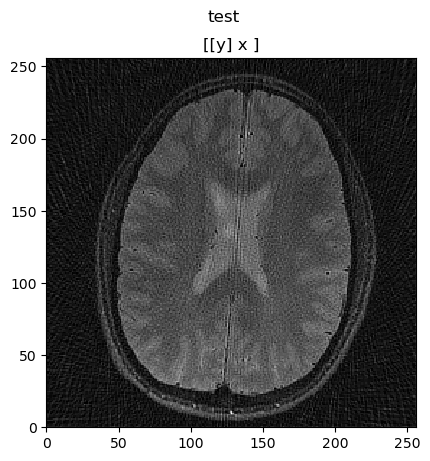

In [ ]:
dcf = np.sqrt(radial_coords[..., 0]**2 + radial_coords[..., 1]**2)
img_grid = sp.nufft_adjoint(radial_kspace * dcf, radial_coords)
img = np.abs(img_grid)
pl.ImagePlot(img, title='test')

## Goal: Simulate a deadtime gap

**Objectives:**

1. For each spoke, remove n points
2. Do same thing for coord data
3. Plot

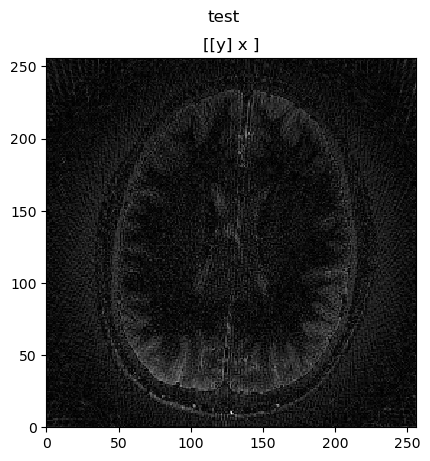

In [ ]:
def point_remove(kspacedata, coord_data, n):
    return kspacedata[:,n:], coord_data[:,n:,:]

radial_kspace, radial_coords = generate_radial_data(ksp=ksp_combined, coord=coord)
radial_kspace, radial_coords = point_remove(kspacedata=radial_kspace, coord_data=radial_coords, n=2)

dcf = np.sqrt(radial_coords[..., 0]**2 + radial_coords[..., 1]**2)
img_grid = sp.nufft_adjoint(radial_kspace * dcf, radial_coords)

img = np.abs(img_grid)
pl.ImagePlot(img, title='test')